<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day1_foundations/Day1_2_Rotation_Animal_Tracking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1 Rotation & Coordinate Transformations in Animal Tracking

## Learning Objectives

By the end of this session, you will be able to:

- Understand 3D rotation matrices and their properties
- Calculate rotation matrices from multi-point animal tracking data
- Convert rotation matrices to meaningful Euler angles (roll, pitch, yaw)
- Understand the difference between intrinsic and extrinsic rotations
- Compare Euler angles vs quaternions for representing orientations
- Transform coordinates between egocentric (animal-centered) and allocentric (world-centered) reference frames

---

## Why This Matters for Behavioral Neuroscience

When tracking animals, we don't just want to know **where** they are (position), but also **how they're oriented** (rotation) such as **what they're looking at** (heading direction). This requires:

1. **Multiple tracking points** on the animal (not just center-of-mass)
2. **Mathematical tools** to compute orientation from those points
3. **Reference frame transformations** to separate ego-centric ("what the animal sees") from allo-centric ("where the animal is in the arena") coordinates

**Example**: A mouse exploring an arena might be moving forward (allocentric translation) while turning its head left (egocentric rotation). Understanding both is crucial for analyzing navigation strategies.

---

## 1. Setup: Import Libraries

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import plotly.express as px
from scipy.spatial.transform import Rotation as R

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# For reproducibility
np.random.seed(42)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---

# Part 1: Rotation Matrices in 3D Space
As we have introduced in the previous colab tutorial, the rotation matrix of 3D space can be written by:

### Basic Rotation Matrices:

**Z-axis**: $\mathbf{R}_z(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta & 0 \\ \sin\theta & \cos\theta & 0 \\ 0 & 0 & 1 \end{bmatrix}$

**X-axis**: $\mathbf{R}_x(\theta) = \begin{bmatrix} 1 & 0 & 0 \\ 0 & \cos\theta & -\sin\theta \\ 0 & \sin\theta & \cos\theta \end{bmatrix}$

**Y-axis**: $\mathbf{R}_y(\theta) = \begin{bmatrix} \cos\theta & 0 & \sin\theta \\ 0 & 1 & 0 \\ -\sin\theta & 0 & \cos\theta \end{bmatrix}$


Each **column** of $\mathbf{R}_1^0$ represents a unit vector of frame 1's axes expressed in frame 0's coordinates:

$$
\mathbf{R}_1^0 = \begin{bmatrix}
| & | & | \\
\mathbf{x}_1^0 & \mathbf{y}_1^0 & \mathbf{z}_1^0 \\
| & | & |
\end{bmatrix}
$$

In [2]:
## TODO write the rotatioin matrix: 

def rotation_matrix_z(theta):
    """Rotation matrix about z-axis by angle theta (in radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ])

def rotation_matrix_x(theta):
    """Rotation matrix about x-axis by angle theta (in radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [1,  0, 0],
        [0,  c, -s],
        [0,  s,  c]
    ])

def rotation_matrix_y(theta):
    """Rotation matrix about y-axis by angle theta (in radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c]
    ])

In [ ]:
# def rotation_matrix_z(theta):
#     """Rotation matrix about z-axis by angle theta (in radians)."""
#     c, s = np.cos(theta), np.sin(theta)
#     return np.array([
#         [c, -s, 0],
#         [s,  c, 0],
#         [0,  0, 1]
#     ])

# def rotation_matrix_x(theta):
#     """Rotation matrix about x-axis by angle theta (in radians)."""
#     c, s = np.cos(theta), np.sin(theta)
#     return np.array([
#         [1,  0, 0],
#         [0,  c, -s],
#         [0,  s,  c]
#     ])

# def rotation_matrix_y(theta):
#     """Rotation matrix about y-axis by angle theta (in radians)."""
#     c, s = np.cos(theta), np.sin(theta)
#     return np.array([
#         [ c, 0, s],
#         [ 0, 1, 0],
#         [-s, 0, c]
#     ])

## 1.2 Visualizing Rotation in 3D

In [3]:
def plot_coordinate_frame(R, origin=[0, 0, 0], scale=1.0, label='', colors=['red', 'green', 'blue']):
    """
    Plot a 3D coordinate frame using Plotly.
    """
    origin = np.array(origin)
    axes = R * scale
    
    traces = []
    axis_names = ['x', 'y', 'z']
    
    for i, (axis, color, name) in enumerate(zip(axes.T, colors, axis_names)):
        traces.append(
            go.Scatter3d(
                x=[origin[0], origin[0] + axis[0]],
                y=[origin[1], origin[1] + axis[1]],
                z=[origin[2], origin[2] + axis[2]],
                mode='lines+markers',
                line=dict(color=color, width=6),
                marker=dict(size=4),
                name=f'{label} {name}',
                showlegend=True
            )
        )
    
    return traces

# Visualize original and rotated frames
fig = go.Figure()

# Original frame
R_original = np.eye(3)
traces_original = plot_coordinate_frame(R_original, origin=[0, 0, 0], scale=1.0, label='Original')

# Rotated frame (45° about z)
R_rotated = rotation_matrix_z(np.pi / 4)
traces_rotated = plot_coordinate_frame(
    R_rotated, 
    origin=[0, 0, 0], 
    scale=1.0, 
    label='Rotated',
    colors=['darkred', 'darkgreen', 'darkblue']
)

for trace in traces_original + traces_rotated:
    fig.add_trace(trace)

fig.update_layout(
    title='Coordinate Frame Rotation (45° about Z-axis)',
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='cube'),
    width=800, height=600
)

fig.show()

---

# Part 2: Computing Rotation from Animal Tracking Data

## 2.1 The Practical Problem

**Question**: If we track a rat with a camera and get (X, Y, Z) positions of markers on its body, how do we calculate the rotation matrix that describes the rat's orientation?

**Answer**: We need **at least 3 non-collinear points** to define a 3D coordinate frame!

### Why at least 3 Points?

A rotation matrix has 3 columns (3 basis vectors), and each column is a 3D unit vector. To uniquely determine these vectors, we need:

1. **Point 1** (e.g., nose) → defines one direction
2. **Point 2** (e.g., tail base) → defines another direction
3. **Point 3** (e.g., left ear) → breaks symmetry, defines the plane

This is why modern animal tracking (DeepLabCut, SLEAP, etc.) always tracks **multiple body parts**!

## 2.2 Mathematical Construction

Given 3 points: **nose** ($\mathbf{p}_n$), **tail base** ($\mathbf{p}_t$), **left ear** ($\mathbf{p}_e$)

### Step 1: Forward Direction (X-axis)
$$\mathbf{x}_{rat} = \frac{\mathbf{p}_n - \mathbf{p}_t}{\|\mathbf{p}_n - \mathbf{p}_t\|}$$

### Step 2: Temporary Left Vector
$$\mathbf{v}_{temp} = \mathbf{p}_e - \mathbf{p}_t$$

### Step 3: Up Direction (Z-axis)
$$\mathbf{z}_{rat} = \frac{\mathbf{x}_{rat} \times \mathbf{v}_{temp}}{\|\mathbf{x}_{rat} \times \mathbf{v}_{temp}\|}$$

### Step 4: True Left Direction (Y-axis)
$$\mathbf{y}_{rat} = \mathbf{z}_{rat} \times \mathbf{x}_{rat}$$

### Step 5: Assemble Matrix
$$\mathbf{R}_{rat}^{arena} = [\mathbf{x}_{rat} \mid \mathbf{y}_{rat} \mid \mathbf{z}_{rat}]$$

## 🎯 EXERCISE 1: Calculate rotation from markers


In [5]:
def compute_rotation_from_markers(nose, tail_base, left_ear):
    """
    Compute rotation matrix from 3 tracked body points.
    
    Parameters:
    -----------
    nose, tail_base, left_ear : array (3,)
        Marker positions [x, y, z]
        
    Returns:
    --------
    R : array (3, 3) - Rotation matrix
    d : array (3,) - Translation vector
    """
    nose = np.array(nose)
    tail_base = np.array(tail_base)
    left_ear = np.array(left_ear)
    
    # Step 1: Forward direction
    ## TODO: compute the forward direction vector (x_axis) from nose and tail_base
    x_axis = nose - tail_base

    x_axis = x_axis / np.linalg.norm(x_axis)
    
    # Step 2: Temporary left vector
    v_temp = left_ear - tail_base
    
    # Step 3: Up direction (cross product)
    z_axis = np.cross(x_axis, v_temp)
    z_axis = z_axis / np.linalg.norm(z_axis)
    
    # Step 4: True left direction
    y_axis = np.cross(z_axis, x_axis)
    # y_axis = y_axis / np.linalg.norm(y_axis)

    
    # Step 5: Assemble rotation matrix
    R = np.column_stack([x_axis, y_axis, z_axis])
    
    # Translation
    d = nose
    
    return R, d


# Example
nose = np.array([1.5, 0.2, 0.1])
tail_base = np.array([0.0, 0.0, 0.0])
left_ear = np.array([0.8, 0.5, 0.15])

R_rat, d_rat = compute_rotation_from_markers(nose, tail_base, left_ear)

print("Rotation matrix (rat → arena):")
print(R_rat)
print(f"\nTranslation: {d_rat}")
print(f"Determinant: {np.linalg.det(R_rat):.6f}")
print(f"Orthogonal: {np.allclose(R_rat.T @ R_rat, np.eye(3))}")

Rotation matrix (rat → arena):
[[ 0.98907071 -0.14372425 -0.03290092]
 [ 0.13187609  0.96213893 -0.23853169]
 [ 0.06593805  0.23158587  0.97057723]]

Translation: [1.5 0.2 0.1]
Determinant: 1.000000
Orthogonal: True


<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python
def compute_rotation_from_markers(nose, tail_base, left_ear):
    """
    Compute rotation matrix from 3 tracked body points.
    
    Parameters:
    -----------
    nose, tail_base, left_ear : array (3,)
        Marker positions [x, y, z]
        
    Returns:
    --------
    R : array (3, 3) - Rotation matrix
    d : array (3,) - Translation vector
    """
    nose = np.array(nose)
    tail_base = np.array(tail_base)
    left_ear = np.array(left_ear)
    
    # Step 1: Forward direction
    ## TODO: compute the forward direction vector (x_axis) from nose and tail_base
    x_axis = nose - tail_base

    x_axis = x_axis / np.linalg.norm(x_axis)
    
    # Step 2: Temporary left vector
    v_temp = left_ear - tail_base
    
    # Step 3: Up direction (cross product)
    z_axis = np.cross(x_axis, v_temp)
    z_axis = z_axis / np.linalg.norm(z_axis)
    
    # Step 4: True left direction
    y_axis = np.cross(z_axis, x_axis)

    
    # Step 5: Assemble rotation matrix
    R = np.column_stack([x_axis, y_axis, z_axis])
    
    # Translation
    d = nose
    
    return R, d
```

**Important notes**:

</details>

### Visualize the Rat's Coordinate Frame

In [6]:
d_rat

array([1.5, 0.2, 0.1])

In [7]:
fig = go.Figure()

# Arena frame
arena_traces = plot_coordinate_frame(np.eye(3), origin=[0, 0, 0], scale=1.5, label='Arena')

# Rat frame
rat_traces = plot_coordinate_frame(
    R_rat, origin=d_rat, scale=1.0, label='Rat',
    colors=['orange', 'darkgreen', 'darkblue']
)
# Markers
for name, pos in [('Nose', nose), ('Tail', tail_base), ('Ear', left_ear)]:
    fig.add_trace(go.Scatter3d(
        x=[pos[0]], y=[pos[1]], z=[pos[2]],
        mode='markers+text', marker=dict(size=8, color='black'),
        text=[name], textposition='top center', name=name
    ))

for trace in arena_traces + rat_traces:
    fig.add_trace(trace)

fig.update_layout(
    title='Rat Coordinate Frame from 3 Tracking Points',
    scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z', aspectmode='cube'),
    width=900, height=700
)

fig.show()

---

# Part 3: From Rotation Matrices to Euler Angles

## 3.1 The Problem

Rotation matrices are **mathematically precise** but **hard to interpret**.

We need **Euler angles**: intuitive rotation amounts about each axis.

There is a key assumpition for interpreting: when the egocentric basis doesn't rotate, the animal is facing forward the arena, horizontally and head not tilled(it matters to choose the correct basis). 

https://howthingsfly.si.edu/flight-dynamics/roll-pitch-and-yaw

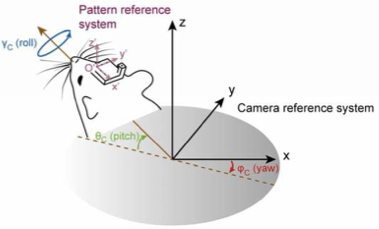

## 3.2 Intrinsic vs Extrinsic Rotations
You can check this website which explain the idea of rotation clearly!
https://dominicplein.medium.com/extrinsic-intrinsic-rotation-do-i-multiply-from-right-or-left-357c38c1abfd

**This is crucial!**

- **Extrinsic (Fixed-Frame)**: Rotations about original (arena) axes
  - Convention: `'xyz'` (lowercase letters)
  - ![gif](attach_figure/extrinsic.gif)
  
- **Intrinsic (Moving-Frame)**: Rotations about current (body) axes  
  - Convention: `'XYZ'` (capital letters)
  - ![gif](attach_figure/intrinsic.gif)

**Key Insight**: Intrinsic `ZYX` = Extrinsic `xyz` (reversed order)

### When to Use:

- **Intrinsic `'ZYX'`**: Animal's perspective ("I turn my head left, then tilt up")
- **Extrinsic `'zyx'`**: Observer's perspective ("Rotate about arena Z, then Y, then X")

## 🎯 EXERCISE 2. Using scipy to get meaningful anlge

  In our case, it will be intrinsic ZYX to get the meaningful roll, yaw, pitch. 

In [8]:
# Convert rotation matrix to Euler angles
r_rat = R.from_matrix(R_rat)

# Intrinsic ZYX (yaw, pitch, roll)
yaw, pitch, roll = ## TODO: compute yaw, pitch, roll from the rotation matrix using intrinsic ZYX convention --- IGNORE ---

print("Euler Angles (Intrinsic - Body Frame):")
print(f"  Yaw   (ψ): {yaw:.2f}° (heading direction)")
print(f"  Pitch (θ): {pitch:.2f}° (nose up/down)")
print(f"  Roll  (φ): {roll:.2f}° (tilt left/right)")

# Extrinsic ZYX
angles_ext = r_rat.as_euler('zyx', degrees=True)
print("\nEuler Angles (Extrinsic ZYX - World Frame):")
print(f"  Z: {angles_ext[0]:.2f}°, Y: {angles_ext[1]:.2f}°, X: {angles_ext[2]:.2f}°")

# Verify
R_reconstructed = r_rat.as_matrix()
print(f"\nReconstruction error: {np.max(np.abs(R_reconstructed - R_rat)):.10f}")

SyntaxError: invalid syntax (3830518163.py, line 5)

<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python
yaw, pitch, roll = r_rat.as_euler('ZYX', degrees=True)
```

**Important notes**:

</details>

### Demonstration: Intrinsic vs Extrinsic

In [7]:
# Same angles, different conventions
angles = [30, 20, 10]  # degrees

r_intrinsic = R.from_euler('zyx', angles, degrees=True)
r_extrinsic = R.from_euler('ZYX', angles, degrees=True)

print("Intrinsic 'zyx' (30°, 20°, 10°):")
print(r_intrinsic.as_matrix())
print("\nExtrinsic 'ZYX' (30°, 20°, 10°):")
print(r_extrinsic.as_matrix())
print(f"\nAre they the same? {np.allclose(r_intrinsic.as_matrix(), r_extrinsic.as_matrix())}")
print(f"Max difference: {np.max(np.abs(r_intrinsic.as_matrix() - r_extrinsic.as_matrix())):.6f}")

Intrinsic 'zyx' (30°, 20°, 10°):
[[ 0.81379768 -0.46984631  0.34202014]
 [ 0.54383814  0.82317294 -0.16317591]
 [-0.20487413  0.31879578  0.92541658]]

Extrinsic 'ZYX' (30°, 20°, 10°):
[[ 0.81379768 -0.44096961  0.37852231]
 [ 0.46984631  0.88256412  0.01802831]
 [-0.34202014  0.16317591  0.92541658]]

Are they the same? False
Max difference: 0.181204


## Excercise: find the correct rotation

There is a dataset with xyz and qauterison(W,X,Y,Z) recorded from rats. 
The only information is the axis y is up, and we don't know about which axis is head direction, which is the side direction. Can you think about a way to figure out the correct roll, yaw pitch?

Hint: 
1. The rotation on y axis now is corresponing to yaw.
2. when in high-speed movement, the movemnt direction is aligend with the head direction(yaw).
3. Try different way to calcualte the movement direction, scatter head direction against head direction, color by the speed. 

## Euler Angles & Quaternions

**Euler angles** (roll, pitch, yaw) are intuitive — they describe rotation as 3 successive rotations around axes. But they suffer from **gimbal lock** (lose a degree of freedom when two axes align).

**Quaternions** $(w, x, y, z)$ avoid this by representing rotation in 4D — no gimbal lock, smooth interpolation, but less human-readable.

$$q = w + xi + yj + zk$$

They are equivalent representations — you can always convert between them.

---

## Converting with SciPy

```python
from scipy.spatial.transform import Rotation as R

# quaternion format: [x, y, z, w] — note scipy uses xyzw order!
r = R.from_quat([qx, qy, qz, qw])

# convert to euler angles (in radians)
# 'zyx' means: first yaw (z), then pitch (y), then roll (x)
roll, pitch, yaw = r.as_euler('zyx')
```
---

## 🎯Exercise: Find the Correct Rotation

There is a dataset with xyz and quaternion (W,X,Y,Z) recorded from rats.
The only information is the axis y is up, the frequency is 50 Hz,and we don't know which axis is head direction, which is the side direction. Can you think of a way to figure out the correct roll, yaw, pitch?

**Hint:**
1. Rotation around the y-axis corresponds to **yaw** (head direction).
2. During high-speed movement, the movement direction aligns with the **head direction** (yaw).
3. Compute movement direction from position
4. Scatter **yaw angle** against **movement direction**, colored by speed — at high speed, they should correlate. That's how you know you found the right convention! 🐀

In [ ]:
# test_data = pd.read_csv('/Users/miao/Documents/phd/behavioral_python/animal_behavior_analysis_in_python/data/rat_pi/rotation_test.csv')
# test_data.head()
!curl -O https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/rat_pi/rotation_test.csv
test_data = pd.read_csv('rotation_test.csv')
test_data.head()
# here x,y,z are the allocentric coordinates, and X,Y,Z,W are the quaternions representing the orientation of the animal.

,x,y,z,X,Y,Z,W
0,-0.177946,0.684947,-0.538020,0.141777,0.896595,0.050038,0.416548
1,-0.176145,0.677317,-0.534851,0.122352,0.923476,0.065979,0.357586
2,-0.173438,0.669224,-0.531853,0.076689,0.941672,0.088131,0.315604
3,-0.171214,0.657547,-0.527501,0.055199,0.949718,0.116545,0.285316
4,-0.168450,0.649601,-0.524621,0.040622,0.949064,0.140375,0.279147


---

# Part 4: Coordinate Frame Transformations

## 4.1 Egocentric vs Allocentric

### Allocentric (World/Arena)
- **Origin**: Fixed in arena
- **Use**: Where is the animal?
- Example: "Food is 30cm from left wall"

### Egocentric (Animal/Body)
- **Origin**: Moves with animal
- **Use**: What does the animal perceive?
- Example: "Food is 10cm to my right"

## 4.2 Transformation Equations

**Egocentric → Allocentric:**
$$\mathbf{p}^{allo} = \mathbf{R}_{ego}^{allo} \mathbf{p}^{ego} + \mathbf{d}_{ego}^{allo}$$

**Allocentric → Egocentric:**
$$\mathbf{p}^{ego} = \mathbf{R}_{ego}^{allo\,T} (\mathbf{p}^{allo} - \mathbf{d}_{ego}^{allo})$$

### Why Transform?
Understanding the animal's *perspective* tells you:
- What they can see (visual field)
- What they're approaching (goal-directed behavior)
- Navigation strategies (landmark-based vs path integration)

## 🎯 EXERCISE 3. Where is the Food?

In [ ]:
def allocentric_to_egocentric(world_point, animal_position, animal_orientation):
    """
    Convert a point from world coordinates to animal's perspective
    
    Parameters:
    -----------
    world_point : array (3,)
        Point location in world frame (e.g., food location)
    animal_position : array (3,)
        Animal's position in world frame
    animal_orientation : Rotation object
        Animal's orientation (from quaternion or Euler angles)
    
    Returns:
    --------
    ego_point : array (3,)
        Point location in animal's reference frame
    """
    ## TODO: implement the transformation from allocentric to egocentric coordinates --- IGNORE ---
    # # Step 1: Translate - vector from animal to point

    # # Step 2: Rotate - transform to animal's frame
    # # Use inverse rotation (transpose) to go from world to body frame
    ego_point = None 
    # ego_point = None
    return ego_point

# Example: Mouse looking for food
print("="*70)
print("EXAMPLE: Mouse Finding Food")
print("="*70)

# World coordinates (allocentric)
food_location_world = np.array([30, 20, 0])  # cm from arena corner
mouse_position = np.array([10, 10, 0])  # Mouse is at (10, 10)
mouse_heading = 45  # Mouse facing 45° from X-axis

# Create mouse orientation
mouse_orientation = R.from_euler('z', mouse_heading, degrees=True)

# Convert food location to mouse's perspective
food_ego = allocentric_to_egocentric(food_location_world, mouse_position, mouse_orientation)

print(f"\nWorld frame (Allocentric):")
print(f"  Mouse position: {mouse_position} cm")
print(f"  Mouse heading: {mouse_heading}°")
print(f"  Food location: {food_location_world} cm")

print(f"\nMouse's perspective (Egocentric):")
print(f"  Food is at: [{food_ego[0]:.1f}, {food_ego[1]:.1f}, {food_ego[2]:.1f}] cm")
print(f"  → {food_ego[0]:.1f} cm in front")
print(f"  → {food_ego[1]:.1f} cm to the left")
print(f"  → {food_ego[2]:.1f} cm above/below eye level")

# Calculate distance and angle to food
distance = np.linalg.norm(food_ego)
angle_to_food = np.degrees(np.arctan2(food_ego[1], food_ego[0]))

print(f"\nBehavioral interpretation:")
print(f"  Distance to food: {distance:.1f} cm")
print(f"  Angle from heading: {angle_to_food:.1f}°")

if abs(angle_to_food) < 30:
    print("  → Food is roughly in front - animal might approach directly")
elif angle_to_food > 30:
    print("  → Food is to the left - animal needs to turn left")
else:
    print("  → Food is to the right - animal needs to turn right")


<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python
def allocentric_to_egocentric(world_point, animal_position, animal_orientation):
    """
    Convert a point from world coordinates to animal's perspective
    
    Parameters:
    -----------
    world_point : array (3,)
        Point location in world frame (e.g., food location)
    animal_position : array (3,)
        Animal's position in world frame
    animal_orientation : Rotation object
        Animal's orientation (from quaternion or Euler angles)
    
    Returns:
    --------
    ego_point : array (3,)
        Point location in animal's reference frame
    """
    ## TODO: implement the transformation from allocentric to egocentric coordinates --- IGNORE ---
    # # Step 1: Translate - vector from animal to point
    relative_vector = world_point - animal_position
    # # Step 2: Rotate - transform to animal's frame
    # # Use inverse rotation (transpose) to go from world to body frame
    ego_point = animal_orientation.inv().apply(relative_vector)
    
    return ego_point
```

**Important notes**:

</details>


## 4.4 Visualization

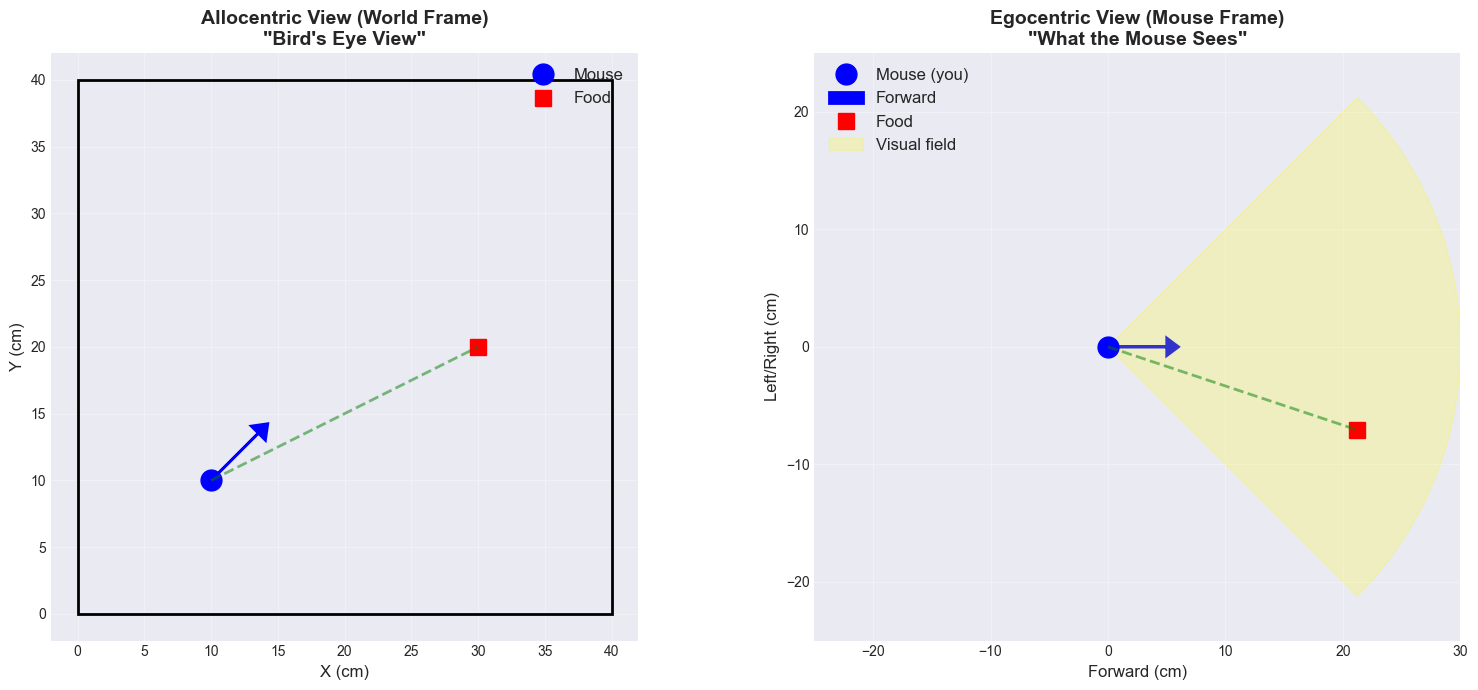


🔍 INTERPRETATION:
LEFT: Where everything is in the room (experimenter's view)
RIGHT: Where everything is from the mouse's perspective

➡️ The food is IN the mouse's visual field - it can see it!
This is crucial for understanding visual guidance of behavior.


In [6]:
def plot_allocentric_egocentric():
    """Visualize both reference frames"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Allocentric view
    mouse_pos = np.array([10, 10])
    food_pos = np.array([30, 20])
    mouse_heading = 45
    
    # Plot arena
    ax1.add_patch(plt.Rectangle((0, 0), 40, 40, fill=False, linewidth=2, edgecolor='black'))
    
    # Plot mouse
    ax1.plot(mouse_pos[0], mouse_pos[1], 'bo', markersize=15, label='Mouse')
    
    # Mouse heading arrow
    heading_vec = 5 * np.array([np.cos(np.radians(mouse_heading)), 
                                np.sin(np.radians(mouse_heading))])
    ax1.arrow(mouse_pos[0], mouse_pos[1], heading_vec[0], heading_vec[1],
             head_width=1.5, head_length=1, fc='blue', ec='blue', linewidth=2)
    
    # Plot food
    ax1.plot(food_pos[0], food_pos[1], 'rs', markersize=12, label='Food')
    
    # Line from mouse to food
    ax1.plot([mouse_pos[0], food_pos[0]], [mouse_pos[1], food_pos[1]], 
            'g--', linewidth=2, alpha=0.5)
    
    ax1.set_xlim(-2, 42)
    ax1.set_ylim(-2, 42)
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel('X (cm)', fontsize=12)
    ax1.set_ylabel('Y (cm)', fontsize=12)
    ax1.set_title('Allocentric View (World Frame)\n"Bird\'s Eye View"', 
                 fontsize=14, fontweight='bold')
    ax1.legend(fontsize=12)
    
    # Egocentric view
    mouse_orientation = R.from_euler('z', mouse_heading, degrees=True)
    food_ego = allocentric_to_egocentric(
        np.append(food_pos, 0), 
        np.append(mouse_pos, 0), 
        mouse_orientation
    )
    
    # Mouse at origin, always facing forward
    ax2.plot(0, 0, 'bo', markersize=15, label='Mouse (you)')
    ax2.arrow(0, 0, 5, 0, head_width=1.5, head_length=1, 
             fc='blue', ec='blue', linewidth=2, label='Forward')
    
    # Food in egocentric frame
    ax2.plot(food_ego[0], food_ego[1], 'rs', markersize=12, label='Food')
    ax2.plot([0, food_ego[0]], [0, food_ego[1]], 'g--', linewidth=2, alpha=0.5)
    
    # Visual field cone
    theta = np.linspace(-np.pi/4, np.pi/4, 50)  # ±45° visual field
    r = 30
    x_cone = r * np.cos(theta)
    y_cone = r * np.sin(theta)
    ax2.fill(np.concatenate([[0], x_cone, [0]]), 
            np.concatenate([[0], y_cone, [0]]), 
            alpha=0.2, color='yellow', label='Visual field')
    
    ax2.set_xlim(-25, 30)
    ax2.set_ylim(-25, 25)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.set_xlabel('Forward (cm)', fontsize=12)
    ax2.set_ylabel('Left/Right (cm)', fontsize=12)
    ax2.set_title('Egocentric View (Mouse Frame)\n"What the Mouse Sees"', 
                 fontsize=14, fontweight='bold')
    ax2.legend(fontsize=12, loc='upper left')
    
    plt.tight_layout()
    return fig

plot_allocentric_egocentric()
plt.show()

print("\n🔍 INTERPRETATION:")
print("LEFT: Where everything is in the room (experimenter's view)")
print("RIGHT: Where everything is from the mouse's perspective")
print("\n➡️ The food is IN the mouse's visual field - it can see it!")
print("This is crucial for understanding visual guidance of behavior.")

## Discussion: why it is important to have different coordinate system 


In the experiment by [Alexander et al., 2020](https://www.science.org/doi/10.1126/sciadv.aaz2322): firing rate can be explained from the egocentric perspective as well
<img src="attach_figure/ego_allo.png" alt="Processed image" align="middle" width="600"/>



## Practice in real data
where is the goal location with regard to the animal? (Rats navigation dataset)
Hint:
1. reconstruct the rotation matrix from roll yaw pitch
2. apply the transformation from allo to ego
3. Visualize the goal location to the rats. 

In [ ]:
## To load the data from the local files 
# DATA_PATH = '../data/rat_pi/processed_long_trials.csv'
# df = pd.read_csv(DATA_PATH)

## load the data from the GitHub repository
!curl -O https://raw.githubusercontent.com/miaowangcissy/animal_behavior_analysis_in_python/main/data/rat_pi/processed_long_trials.csv
import pandas as pd
df = pd.read_csv('processed_long_trials.csv')
df.head()
print(f"Loaded {df['trial_id'].nunique()} trials")
display(df.head())
test_trial = df[df['trial_id'] == df['trial_id'].iloc[0]].copy()

Loaded 139 trials


,comp_time,time,trial_id,frame,success,visible,x,y,z,roll,yaw,pitch,rearing,goal_x,goal_z,session_id
0,1.642678e+09,0.00,0,0,1,1,-0.177946,0.684947,-0.538020,17.219877,130.408251,1.626639,1,-0.222463,-0.506765,20220120-122427
1,1.642678e+09,0.02,0,1,1,1,-0.176145,0.677317,-0.534851,15.862311,137.391134,-1.968877,1,-0.222463,-0.506765,20220120-122427
2,1.642678e+09,0.04,0,2,1,1,-0.173438,0.669224,-0.531853,11.622204,142.254633,-6.752198,0,-0.222463,-0.506765,20220120-122427
3,1.642678e+09,0.06,0,3,1,1,-0.171214,0.657547,-0.527501,10.051063,145.591786,-10.945343,0,-0.222463,-0.506765,20220120-122427
4,1.642678e+09,0.08,0,4,1,1,-0.168450,0.649601,-0.524621,9.225046,146.075703,-14.109203,0,-0.222463,-0.506765,20220120-122427


---

# 📝 Summary & Key Takeaways

## What We Learned:

### 1. Rotation Matrices
- Belong to $SO(3)$: orthogonal, det=1, $\mathbf{R}^{-1} = \mathbf{R}^T$
- Columns = basis vectors of rotated frame

### 2. Computing from Tracking
- Need 3+ non-collinear points
- Use cross products for orthogonality

### 3. Euler Angles
- **Intrinsic** (`'zyx'`): body-frame rotations
- **Extrinsic** (`'ZYX'`): world-frame rotations
- Gimbal lock at pitch = ±90°

### 4. Quaternions
- No gimbal lock
- Better for interpolation
- Less intuitive

### 5. Frame Transformations
- Allocentric: fixed world frame
- Egocentric: animal's perspective
- $\mathbf{p}^{allo} = \mathbf{R} \mathbf{p}^{ego} + \mathbf{d}$

---

## 🔬 Applications:

✅ Head direction analysis
✅ Gaze estimation
✅ Postural dynamics
✅ Egocentric mapping
✅ Navigation strategies

---

## 📚 Resources:

- "Robot Modeling and Control" (Spong et al.)
- [scipy.spatial.transform.Rotation docs](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.transform.Rotation.html)
- 3Blue1Brown: "Quaternions and 3D Rotation"

---

## 🏠 Homework:

1. Apply Gaussian smoothing to Euler angles
2. Implement SLERP for quaternion interpolation
3. Detect rapid head turns (high yaw velocity)
4. Analyze your own tracking data!

---

**Tomorrow**: DeepLabCut pose estimation! 🎉